In [17]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime,timedelta
import pandas as pd

import niskine
import mplniw.plot as pl
import gvpy as gv
import mplniw.sigp as sp
import mplniw.utils as ut
import matplotlib.ticker as tkr
import matplotlib.lines as mlines


import matplotlib as mpl

mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

In [18]:
#Load moorings config
mooring=1
conf = niskine.io.load_config()
lon, lat, bottom_depth = niskine.io.mooring_location(mooring=mooring)
#Directories
root_dir = '/Users/zcasparcohen/codes/NIW/'
figdir = '/Users/zcasparcohen/Documents/Figures_paper/'

In [19]:
#Moorings config
m1lon, m1lat, m1bottom_depth = niskine.io.mooring_location(mooring=1)
m2lon, m2lat, m2bottom_depth = niskine.io.mooring_location(mooring=2)
m3lon, m3lat, m3bottom_depth = niskine.io.mooring_location(mooring=3)

In [20]:
# Wind
wind_work = xr.open_dataset(root_dir+'data/ni_wind_work_niskine_m1.nc').rename({'__xarray_dataarray_variable__':'wind_work'})
wind_stress = xr.open_dataset(root_dir+'data/wind_work/wind_stress_niskine_m1.nc')

#Velocity time series
ds = xr.open_dataset(root_dir+'data/NI02_M%s.nc'%mooring)
gridded=xr.open_dataset(root_dir+'data/M%s_linear_merge_slinearfill.nc'%mooring)[['u','v']]
wkb = niskine.clim.get_wkb_factors(gridded)
ds['bpuz'] = wkb*ds['u_filtered'].differentiate('z')
ds['bpvz'] = wkb*ds['v_filtered'].differentiate('z')

ds['uz'] = wkb*ds['u'].differentiate('z')
ds['vz'] = wkb*ds['v'].differentiate('z')

#Vorticity
vort = xr.open_dataset(root_dir+'data/vorticity_moorings.nc')
vort_alt = xr.open_dataset(root_dir+'data/vorticity_alt.nc')

#N
N2 = xr.open_dataset(root_dir+'data/N_daily.nc').rename({'__xarray_dataarray_variable__':'N2'})

#Low frequency motion
ds_low = xr.open_dataset(root_dir+'data/M%s_lpfiltered.nc'%mooring).interpolate_na(dim='time',method='cubic',max_gap=pd.Timedelta(3, "d"))

alt = niskine.io.load_ssh()
alt['eke'] = 1/2 * (alt.ugosa**2 + alt.vgosa**2)
from datetime import datetime
eke = alt.eke.sel(time=slice('2019-06-01','2020-10-01'))#.plot()
_time = eke.time

In [21]:
alt['ugos_mean'] = alt.ugos.mean('time')
alt['vgos_mean'] = alt.vgos.mean('time')

In [22]:
#Coordinates of the center of the mooring array 
latitudes = [m*np.pi/180 for m in [m1lat,m2lat,m3lat]]
longitudes = [m*np.pi/180 for m in [m1lon,m2lon,m3lon]]
sumx = np.sum(np.cos(latitudes)*np.cos(longitudes))/3
sumy = np.sum(np.cos(latitudes)*np.sin(longitudes))/3
sumz = np.sum(np.sin(latitudes))/3
midlon = 180*np.arctan2(sumy,sumx)/np.pi
hyp = np.sqrt(sumx*sumx+sumy*sumy)
midlat = 180*np.arctan2(sumz,hyp)/np.pi

In [23]:
import cartopy.crs as ccrs
import cmocean
import matplotlib.path as mpath
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER,LatitudeLocator, LongitudeLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import matplotlib.ticker as mticker

In [24]:
#Topography from NOAA
topo = xr.open_dataset('/Users/zcasparcohen/Downloads/ETOPO_2022_v1_30s_N90W180_bed.nc').z.sel(lon=slice(-30,-15.3),lat=slice(55,64.8))
topo = topo.isel(lon=slice(0,None,1),lat=slice(0,None,1))

In [25]:
#eke from altimatry on topography grid
_  = eke.mean('time').interp(lon=topo.lon,lat=topo.lat)

In [26]:
_ = _.where(topo<0)

In [27]:
#Vorticity from altimetry
_vort = vort_alt.__xarray_dataarray_variable__.sel(time='2019-11-12').interp(lon=topo.lon,lat=topo.lat)
_vort = _vort.where(topo<-200)

### Figure 1: Iceland Basin

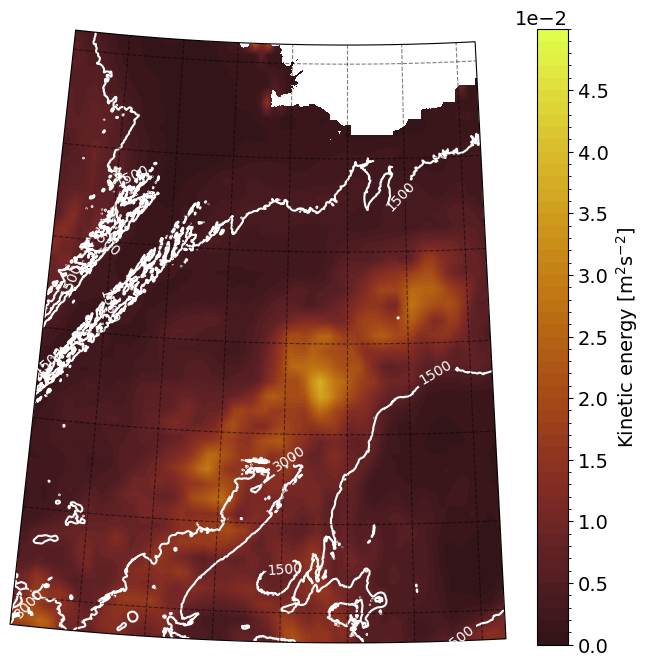

In [28]:
# Mean EKE from altimetry in Iceland Basin 

subplot_kws=dict(projection=ccrs.LambertConformal(central_longitude=-20.0,central_latitude=60.0),
                 facecolor='white')

fig=plt.figure(figsize=[8,8])
p = _.plot.pcolormesh(x='lon', y='lat',
                  vmin=0, vmax=5e-2,
                  cmap=cmocean.cm.solar,
                  subplot_kws=subplot_kws,
                  transform=ccrs.PlateCarree(),
                  levels=51,
                  add_labels=False,
                  add_colorbar=True,cbar_kwargs={'label':r'Kinetic energy [m$^2$s$^{-2}$]','ticks':np.arange(0,5e-2,5e-3)})
#cbar = fig.colorbar(p,label=r'Kinetic energy [m$^2$s$^{-2}$]')

p.colorbar.formatter.set_powerlimits((0, 0))
# add separate colorbar
#cb = plt.colorbar(p, ticks=np.arange(0,5e-2,1e-2), shrink=0.99)
#cb.ax.tick_params(labelsize=18)
n = 20
aoi = mpath.Path(
    list(zip(np.linspace(-30,-15.3, n), np.full(n, 64.8))) + \
    list(zip(np.full(n, -15.3), np.linspace(64.8, 55, n))) + \
    list(zip(np.linspace(-15.3, -30, n), np.full(n, 55))) + \
    list(zip(np.full(n, -30), np.linspace(55, 64.8, n)))
)

p.axes.set_boundary(aoi, transform=ccrs.PlateCarree())
cs = (-1*topo).plot.contour(ax=p.axes,transform=ccrs.PlateCarree(),colors='w',levels=[1500,3000],linestyles='-')
p.axes.clabel(cs,inline=True)
gl = p.axes.gridlines(color='black', alpha=0.5, linestyle='--',draw_labels=False)

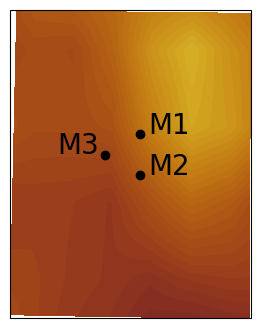

In [29]:
#Zoom in moorings area
subplot_kws=dict(projection=ccrs.LambertConformal(central_longitude=-20.0,central_latitude=60.0),
                 facecolor='white')

fig=plt.figure(figsize=[4,4])
p = _.sel(lon=slice(-22,-20.5),lat=slice(58.5,59.5)).plot.contourf(x='lon', y='lat',
                  vmin=0, vmax=5e-2,
                  cmap=cmocean.cm.solar,
                  subplot_kws=subplot_kws,
                  transform=ccrs.PlateCarree(),
                  levels=51,
                  add_labels=False,
                  add_colorbar=False)

p.axes.scatter([m1lon,m2lon,m3lon],[m1lat,m2lat,m3lat],c='k', transform=ccrs.PlateCarree())
p.axes.text(m1lon+0.05,m1lat, 'M1',size=20,transform=ccrs.PlateCarree());p.axes.text(m2lon+0.05,m2lat, 'M2',size=20,transform=ccrs.PlateCarree());
p.axes.text(m3lon-0.3,m3lat, 'M3',size=20,transform=ccrs.PlateCarree());


### Figure 2: Regional properties

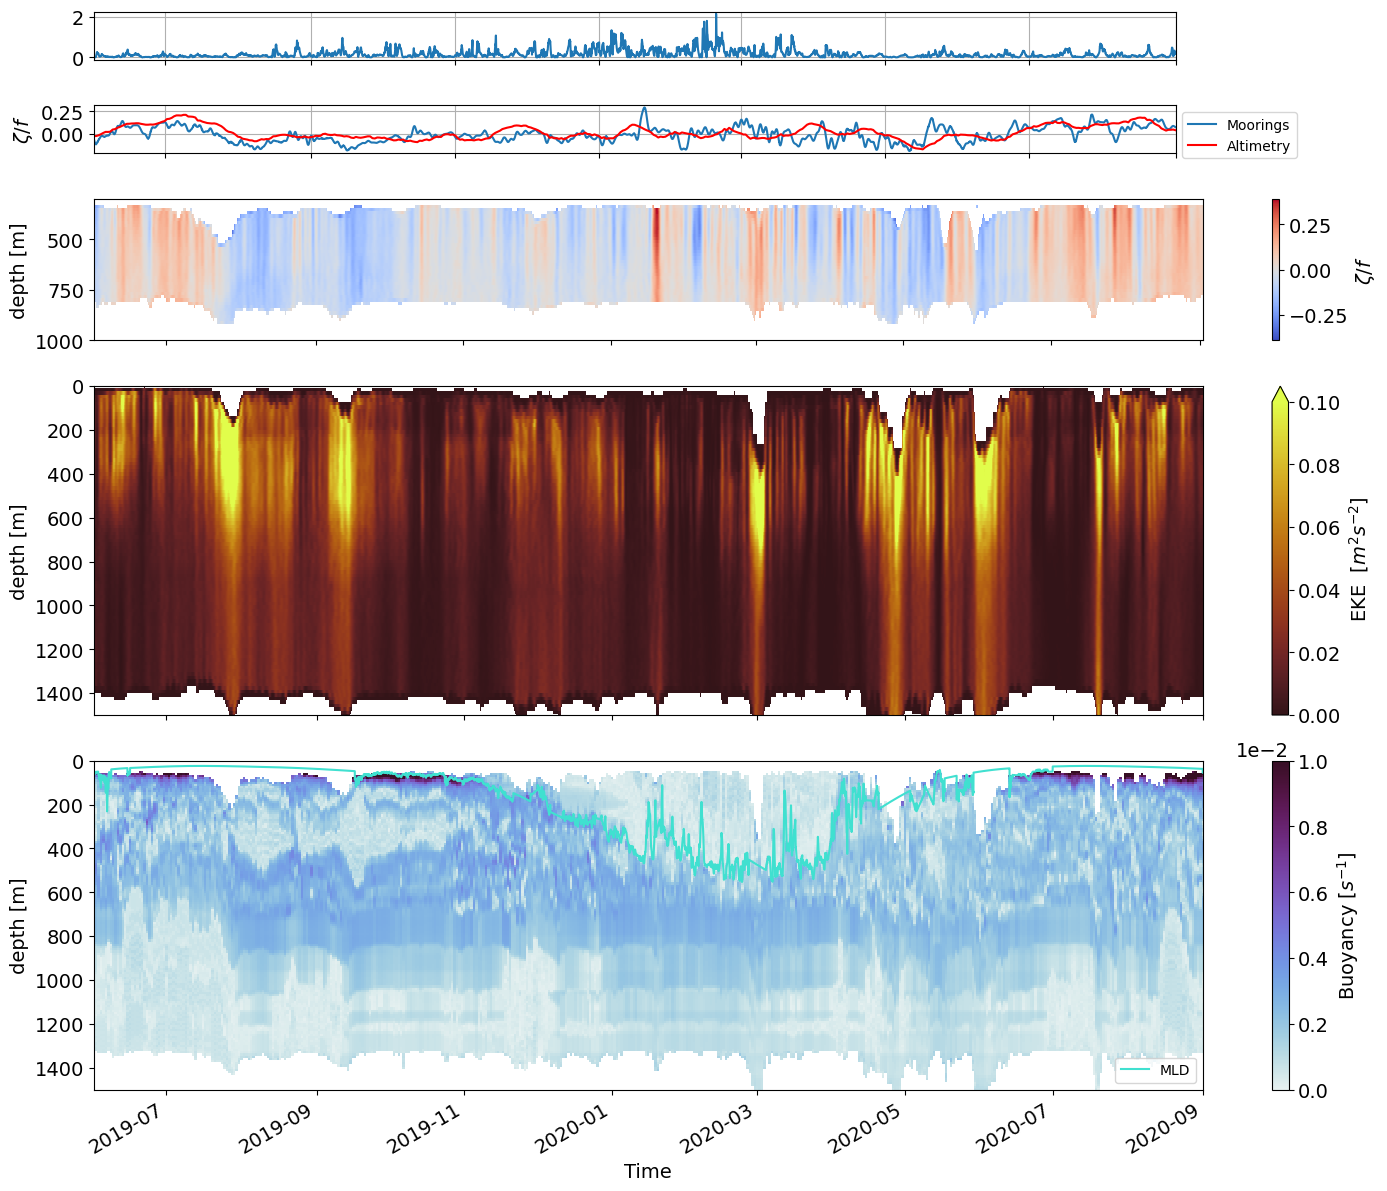

In [30]:
#fig,axs = plt.subplots(3,1,figsize=(10,6),sharex=True)
fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(12,5)
ax = fig.add_subplot(gs[:1,:-1])
wind_stress['__xarray_dataarray_variable__'].plot(ax=ax)
ax.grid();ax.set_title('');ax.set_ylabel(r'') #Wind stress \\ [$N m^{-2}$]
ax.set_xlabel('');#ax.set_title('');ax.grid();
ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-09-01'))
plt.setp( ax.get_xticklabels(), visible=False)

ax = fig.add_subplot(gs[1:2,:-1])
vort.vorticity_norm.sel(time=slice('2019-06-01','2020-09-01')).mean('z').plot(ax=ax,label='Moorings')
vort_alt.__xarray_dataarray_variable__.sel(lon=midlon,lat=midlat,method='nearest').sel(time=slice('2019-06-01','2020-09-01')).plot(ax=ax,c='r',label='Altimetry')
ax.grid();ax.set_title('');ax.legend(bbox_to_anchor=(1,1))
#ax.legend(loc='upper right')
ax.set_ylabel(r'$\zeta / f$')
ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-09-01'))
plt.setp( ax.get_xticklabels(), visible=False);ax.set_xlabel('');

ax = fig.add_subplot(gs[2:4,:])
vort.vorticity_norm.sel(time=slice('2019-06-01','2020-09-01')).plot(ax=ax,yincrease=False,label='Moorings',ylim=(1000,300),cmap='coolwarm')
#vort_alt.__xarray_dataarray_variable__.sel(lon=midlon,lat=midlat,method='nearest').sel(time=slice('2019-06-01','2020-09-01')).plot(ax=ax,c='r',label='Altimetry')
#ax.grid();ax.set_title('');ax.legend()
#ax.set_ylabel(r'$\zeta / f$')
#ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-09-01'))
plt.setp( ax.get_xticklabels(), visible=False);ax.set_xlabel('');

ax = fig.add_subplot(gs[4:8,:])
(0.5*(ds_low.u_filtered**2+ds_low.v_filtered**2)).plot(ax=ax,yincrease=False,ylim=(1500,0),vmax=1e-1,vmin=0,cmap=cmocean.cm.solar,cbar_kwargs={'label':r'EKE  [$m^2 s^{-2}$]'})
#ds.mld.plot(ax=ax);ax.set_ylabel('depth [m]')
ax.set_ylim(1500,0)
ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-09-01'))
plt.setp( ax.get_xticklabels(), visible=False);ax.set_xlabel('');

ax = fig.add_subplot(gs[8:,:])
cs = np.sqrt(N2.N2).plot(ax=ax,yincrease=False,ylim=(1500,0),vmax=1e-2,vmin=0,cmap=cmocean.cm.dense,add_colorbar=False)
ds.mld.plot(ax=ax,c='turquoise',label='MLD');ax.set_ylabel('depth [m]')
cbar = fig.colorbar(cs,label=r'Buoyancy [$s^{-1}$]')
cbar.formatter.set_powerlimits((0, 0))
ax.set_ylim(1500,0);ax.legend(loc='lower right')
ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-09-01'))
ax.set_xlabel('Time')

#fig.subplots_adjust(hspace=0.15)
fig.tight_layout()
fig.savefig(figdir+'area_properties.jpg')

### Figure 3: Near Inertial Kinetic energy

In [31]:
moorings={}
for mooring in [1,2,3]:
    #gridded=xr.open_dataset(root_dir+'M%s_linear_merge_slinearfill.nc'%mooring)[['u','v']]
    ds = xr.open_dataset(root_dir+'data/NI02_M%s.nc'%mooring)
    mld_m1 = xr.open_dataarray(conf.data.ml.mld).sel(time=slice(ds.time[0],ds.time[-1]))
    ds['mld'] = mld_m1
    gridded=xr.open_dataset(root_dir+'data/M%s_linear_merge_slinearfill.nc'%mooring)[['u','v']]
    wkb = niskine.clim.get_wkb_factors(gridded)
    ds['bpuz'] = wkb*ds['u_filtered'].differentiate('z')
    ds['bpvz'] = wkb*ds['v_filtered'].differentiate('z')
    ds['uz'] = ds['u'].differentiate('z')
    ds['vz'] = ds['v'].differentiate('z')
    ds['UVz'] = ds.uz + 1j*ds.vz
    moorings[str(mooring)] = ds

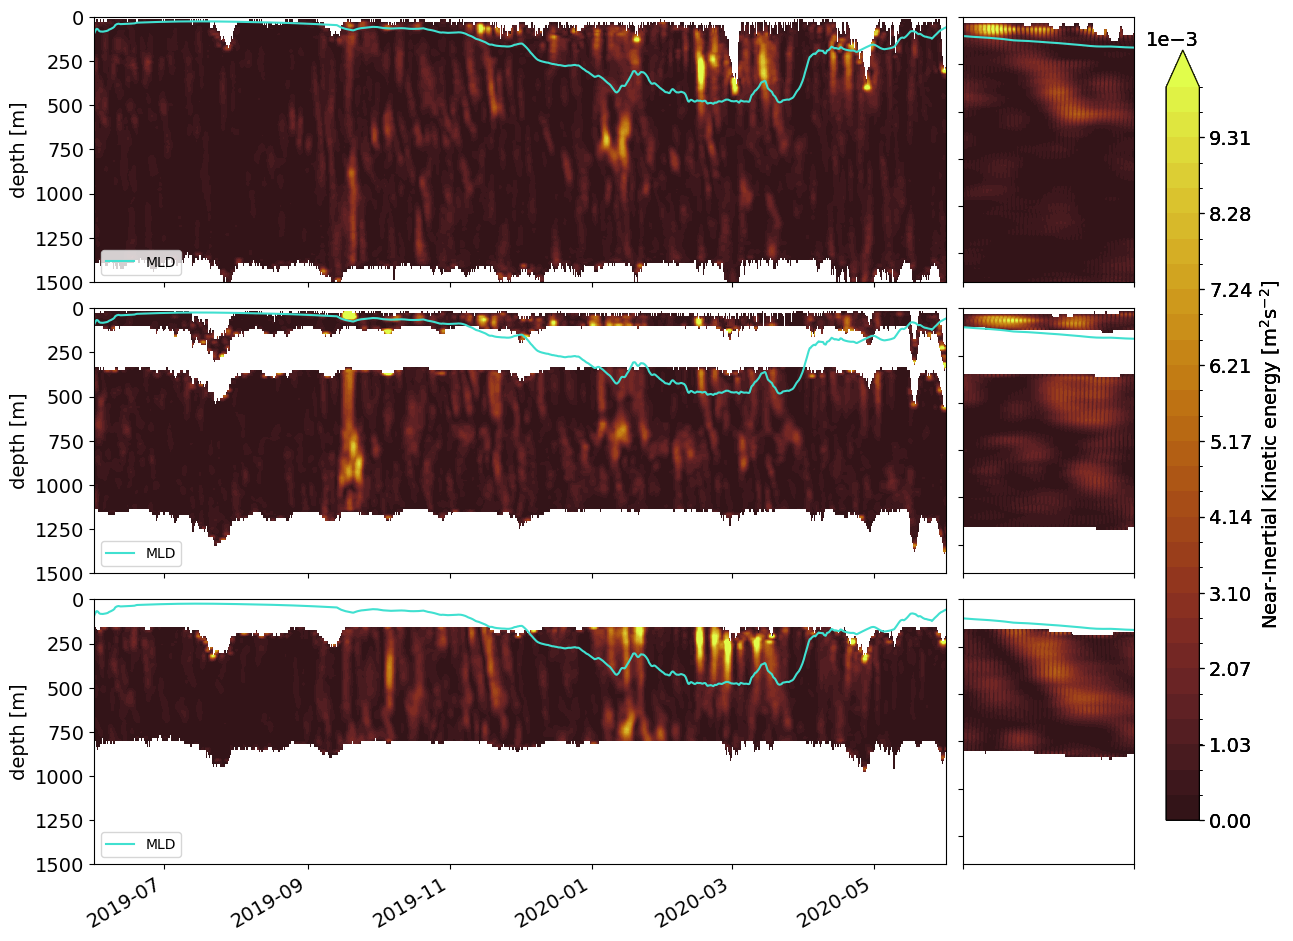

In [32]:
fig,axs = plt.subplots(3,1,figsize=(11,11),sharex=True)
for i,m in enumerate(moorings):
    ax = axs[i]
    c1 = moorings[m].ni_ke_wkb.plot.contourf(ax=ax,yincrease=False,levels=30,ylim=(1500,0),vmax=0.01,vmin=0,
                                             add_colorbar=False,cmap=cmocean.cm.solar)
   # if m=='1':
    moorings['1'].mld.rolling({'time':1000}).mean().shift({'time':-500}).plot(ax=ax,c='turquoise',label='MLD')
    
    ax.set_ylabel('depth [m]');ax.legend()
    ax.set_xlabel('');ax.set_title('')
    ax.set_xlim(np.datetime64('2019-06-01'),np.datetime64('2020-06-01'))
    # inset Axes....
    x1, x2, y1, y2 = np.datetime64('2019-11-12'),np.datetime64('2019-11-24'), 1400,0  # subregion of the original image
    axins = ax.inset_axes([1.02, 0., 0.2, 1],xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
    cb = moorings[m].ni_ke_wkb.plot.contourf(ax=axins,yincrease=False,levels=30,vmax=0.01,vmin=0,
                                             add_colorbar=False,cmap=cmocean.cm.solar)
    moorings['1'].mld.rolling({'time':1000}).mean().sel(time='2019-11').plot(ax=axins,c='turquoise',label='MLD')
    axins.set_ylabel('');axins.set_xlabel('');axins.set_xticks([x1,x2])
    cbar_ax = fig.add_axes([1.1, 0.15, 0.03, 0.7])
    cbar=fig.colorbar(cb, cax=cbar_ax,label=r'Near-Inertial Kinetic energy [m$^2$s$^{-2}$]'
                     ,ticks=[0.,1.03*1e-3,2.07*1e-3,3.10*1e-3,4.14*1e-3,5.17*1e-3,6.21*1e-3,7.24*1e-3,8.28*1e-3,9.31*1e-3])
    cbar.formatter.set_powerlimits((0, 0))
    ticks = cbar.get_ticks()

fig.subplots_adjust(hspace=0.1)

### Figure 4

In [33]:
import seaborn as sns
import mixsea

#### Figure 4a: Shear spectra

In [15]:
#Compute shear spectra
CW,CCW,P,m = mixsea.helpers.psd(ds.UVz.isel(time=5100).sel(z=slice(400,900)).dropna('z'),16,axis=0,ffttype='t',detrend=True)
m_max = m.max()

In [16]:
def wrap_psd(ds,t):
    x = ds.UVz.sel(time=t).dropna('z')
    if x.size>10:
        CW,CCW,P,m = mixsea.helpers.psd(x,16,axis=0,ffttype='t',detrend=True)
    else:
        CW = np.full((42,),np.nan)
        P = np.full((42,),np.nan)
        CCW = np.full((42,),np.nan)
        m = np.linspace(0,m_max,42)
    ds_out = xr.Dataset({'CW':(['m'],CW),'CCW':(['m'],CCW),'P':(['m'],P),'m':(['m'],m)})
    return ds_out

In [17]:
#Compute shear spectra for all morrings
P_moorings = {}
for mooring in [1,2,3]:
    _ds = xr.concat([wrap_psd(moorings[str(mooring)].sel(z=slice(400,900)),t) for t in ds.time.values],'time')
    _ds = _ds.assign_coords({'time':ds.time.values})
    P_moorings[str(mooring)] = _ds

In [55]:

wmax,wmin = 320,64
_time = ds.time[::24*6]

In [56]:
#Assign vorticity sign to shear profiles
_ = P_moorings['1']
zeta_sign = np.zeros(_.time.size)
tt = vort.where(vort.vorticity_norm.mean('z')<0).vorticity_norm.mean('z')
ig = ~np.isnan(tt)
zeta_sign[ig] = 1

In [57]:
#Assign vorticity sign to shear profiles
for i,mooring in enumerate(P_moorings):
    _ds = P_moorings[mooring]
    _ds['zeta_sign'] = xr.Dataset({'zeta_sign':(['time'],zeta_sign),'time':(['time'],_ds.time.data)}).zeta_sign
    _ds['zeta_sign'].attrs.update({'long_name':r'$\zeta/f$'})

In [18]:

#P_m = xr.concat([P_moorings[m] for m in moorings],dim='mooring').assign_coords({'mooring':[1,2,3]})
ds_moorings = xr.concat([moorings[m] for m in moorings],dim='mooring').assign_coords({'mooring':[1,2,3]}) # create dataset from dict

In [35]:
#Contours for PDF 2D plot (seaborn toolbox)
n=1
x_contour = np.log10(P_m['CW'].sel(time=slice('2019-09-01','2020-06-01')).fillna(0).integrate('m').interp({'time':vort.time[::n*6]}).values.flatten())
y_contour = np.log10(ds_moorings.ni_ke.sel(time=slice('2019-09-01','2020-06-01'),z=slice(300,900)).interp({'time':vort.time[::n*6]}).mean('z').values.flatten())
hue_contour = P_m['zeta_sign'].interp({'time':vort.time[::n*6]}).values.flatten()

x = np.log10(P_m['CW'].sel(mooring=1).sel(time=slice('2019-09-01','2020-06-01')).fillna(0).integrate('m').interp({'time':vort.time[::n*6]}).values.flatten())
y = np.log10(ds_moorings.ni_ke.sel(mooring=1).sel(time=slice('2019-09-01','2020-06-01'),z=slice(300,900)).interp({'time':vort.time[::n*6]}).mean('z').values.flatten())
hue = P_m['zeta_sign'].sel(mooring=1).interp({'time':vort.time[::n*6]}).values.flatten()

/Users/zcasparcohen/miniconda3/envs/mpl_niw/lib/python3.11/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'c'
  cset = contour_func(


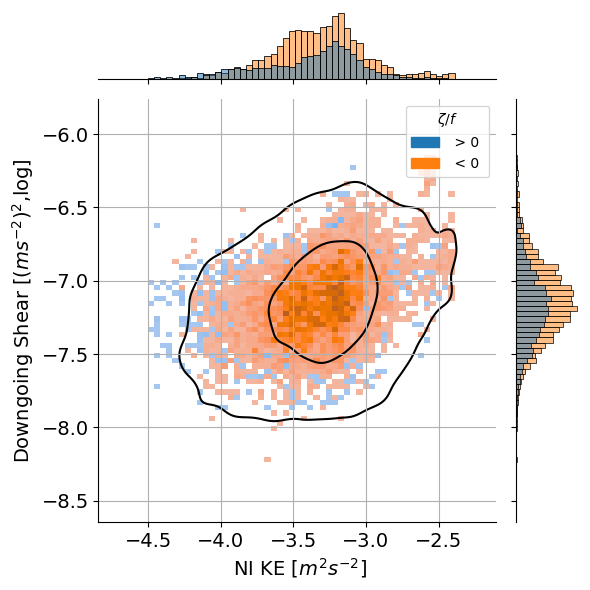

In [36]:
#fig,ax = plt.subplots(figsize=(6,6))
g = sns.jointplot(x=y,y=x,hue=hue,kind='hist',height=6)
#
ax=g.ax_joint
sns.kdeplot(x=y_contour,y=x_contour,ax=ax,c='k',zorder=1,levels=3)
ax.legend_.set_title(r"$\zeta / f$")
for label in ax.legend_.texts:
    if label.get_text() == "0.0":
        label.set_text(" > 0 ")
    else:
        label.set_text(" < 0")
#ax.set_xlim(0,0.002);ax.set_ylim(-8.5,-6)
ax.set_xlabel(r' NI KE [$m^2 s^{-2}$]')
ax.set_ylabel(r'Downgoing Shear [($m s^{-2})^2$,log]')
ax.grid()
plt.tight_layout()
plt.savefig(figdir+'shear_nike.jpg')

/Users/zcasparcohen/miniconda3/envs/mpl_niw/lib/python3.11/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'c'
  cset = contour_func(


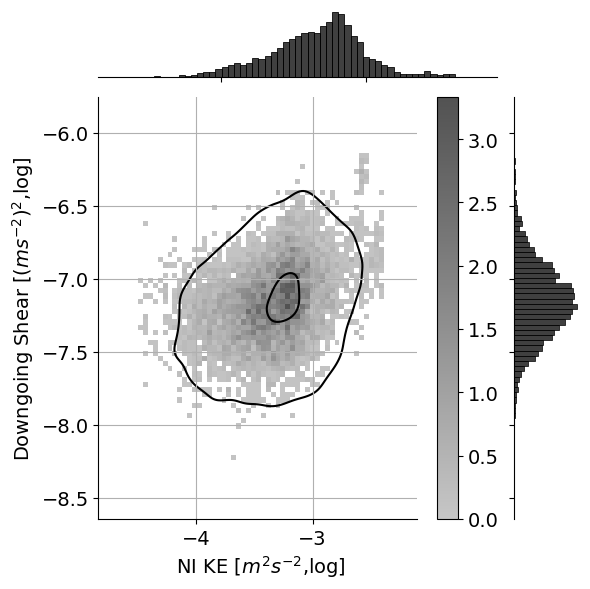

In [196]:
g = sns.jointplot(x=y,y=x,kind='hist',height=6,color='k',stat='density',pmax=1,cbar=True)
#
ax=g.ax_joint
cs = sns.kdeplot(x=y_contour,y=x_contour,ax=ax,zorder=1,c='k',levels=[0.10,0.9])
#plt.clabel(cs, cs.levels, inline=True)
#ax.set_xlim(0,0.002);ax.set_ylim(-8.5,-6)
ax.set_xlabel(r' NI KE [$m^2 s^{-2}$,log]')
ax.set_ylabel(r'Downgoing Shear [($m s^{-2})^2$,log]')
ax.grid()
plt.tight_layout()
#plt.savefig(figdir+'shear_nike.jpg')

#### Figure 4b: NI KE, vorticity and stratification

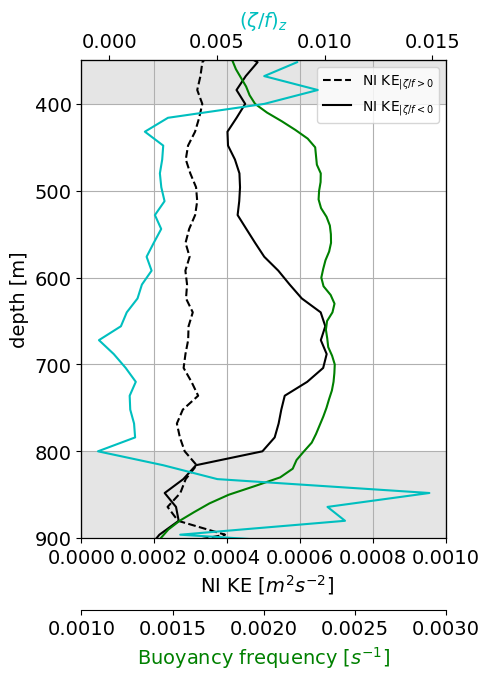

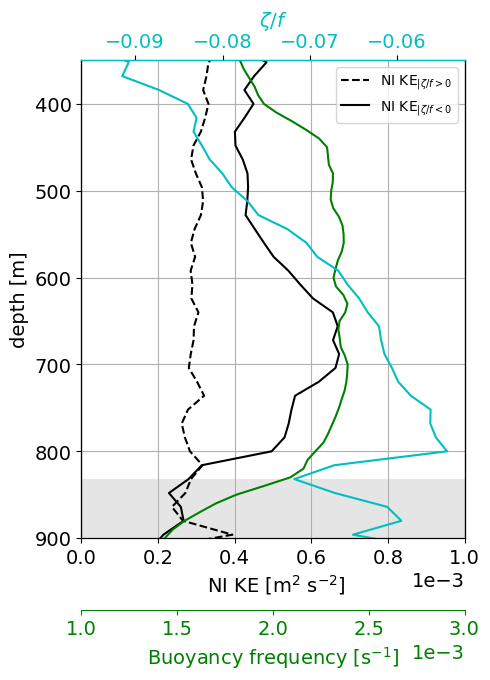

In [69]:
fig,ax = plt.subplots(1,1,figsize=(5,7))
moorings['1'].ni_ke.where(vort.vorticity_norm>0).mean('time').plot(ax=ax,y='z',yincrease=False,xlim=(0,1e-3),c='k',ls='--',label=r'NI KE$_{\vert\zeta/f>0}$')
moorings['1'].ni_ke.where(vort.vorticity_norm<0).mean('time').plot(ax=ax,y='z',yincrease=False,xlim=(0,1e-3),c='k',ls='-',label=r'NI KE$_{\vert\zeta/f<0}$')
ax.set_xlabel(r' NI KE [$m^2 s^{-2}$]');ax.grid()
ax.fill_between(np.linspace(0,1e-3,50), 300, 400, fc='grey', alpha=0.2)
ax.fill_between(np.linspace(0,1e-3,50), 800, 900, fc='grey', alpha=0.2)
ax.legend()
ax1 = ax.twiny()
np.sqrt(N2.N2.mean('time')).plot(ax=ax1,y='depth',yincrease=False,xlim=(1e-3,3e-3),ylim=(900,350),c='g')
ax1.set_xlabel(r'Buoyancy frequency [$s^{-1}$]',c='g')
ax1.xaxis.set_label_position('bottom')
ax1.set_title('');
ax1.spines.bottom.set_position(("axes", -0.15))
ax.set_title('');
ax2 = ax1.twiny()
vort.vorticity_norm.where(vort.vorticity_norm<0).diff('z').mean('time').plot(ax=ax2,y='z',yincrease=False,c='c')
ax2.set_xlabel(r'$(\zeta / f)_z$',c='c')
#ax2.axvline(0,ls='--',zorder=-1,c='grey')
ax2.set_title('')
#axs[1].set_ylabel('')
fig.tight_layout()
fig.savefig(figdir+'mean_profiles.jpg')

fig,ax = plt.subplots(1,1,figsize=(5,7))

moorings['1'].ni_ke.where(vort.vorticity_norm>0).mean('time').plot(ax=ax,y='z',yincrease=False,xlim=(0,1e-3),c='k',ls='--',label=r'NI KE$_{\vert\zeta/f>0}$')
moorings['1'].ni_ke.where(vort.vorticity_norm<0).mean('time').plot(ax=ax,y='z',yincrease=False,xlim=(0,1e-3),c='k',ls='-',label=r'NI KE$_{\vert\zeta/f<0}$')
ax.set_xlabel(r' NI KE [m$^2$ s$^{-2}$]');ax.grid()
ax.fill_between(np.linspace(0,1e-3,50), 300, 336, fc='grey', alpha=0.2)
ax.fill_between(np.linspace(0,1e-3,50), 832, 900, fc='grey', alpha=0.2)
ax.axes.ticklabel_format(axis='x', style='sci',scilimits=((0,0)))
ax.legend();ax.set_title('');

ax1 = ax.twiny()
np.sqrt(N2.N2.mean('time')).plot(ax=ax1,y='depth',yincrease=False,xlim=(1e-3,3e-3),ylim=(900,350),c='g')
ax1.set_xlabel(r'Buoyancy frequency [s$^{-1}$]',c='g')
ax1.xaxis.set_label_position('bottom')
ax1.set_title('');
ax1.spines.bottom.set_position(("axes", -0.15))
ax1.axes.ticklabel_format(axis='x', style='sci',scilimits=((0,0)))
ax1.tick_params(axis='x', colors='g')
ax1.spines['bottom'].set_color('g')


ax2 = ax1.twiny()
vort.vorticity_norm.where(vort.vorticity_norm<0).mean('time').plot(ax=ax2,y='z',yincrease=False,c='c')
ax2.set_xlabel(r'$\zeta / f$',c='c')
ax2.set_title('')
[t.set_color('c') for t in ax2.xaxis.get_ticklabels()]
ax2.spines['top'].set_color('c')

fig.tight_layout()

### Figure 5 : Dissipation rate

In [34]:
#Load dissipation rate file
eps = xr.open_dataset(root_dir+'data/eps.nc')
eps_small = xr.open_dataset(root_dir+'data/eps_small.nc')

ds = moorings['1']
t0,t1,t2 = '2019-11-14','2019-11-18','2019-11-20'
import matplotlib.lines as mlines
depth_max,depth_min = 1400,75

In [35]:
import gsw
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


In [36]:
eps_t = eps.eps.sel(depth_bin=slice(200,1000)).mean('depth_bin')
nike_t=ds.ni_ke.sel(z=slice(200,1000)).mean('z')

In [37]:
# Reconstructiing stratification: load SBE56s measurements
SBE_12710 = xr.open_dataset(root_dir+'data/SBE37_12710_NISKINE.nc').interp(time=ds.time)
SBE_12711 = xr.open_dataset(root_dir+'data/SBE37_12711_NISKINE.nc').interp(time=ds.time)
SBE_12712 = xr.open_dataset(root_dir+'data/SBE37_12712_NISKINE.nc').interp(time=ds.time)
SBE_2864 = xr.open_dataset(root_dir+'data/SBE37_2864_NISKINE.nc').interp(time=ds.time)
SBE_4923 = xr.open_dataset(root_dir+'data/SBE37_4923_NISKINE.nc').interp(time=ds.time)

In [38]:
SBE37 = xr.concat([SBE_4923,SBE_2864,SBE_12710,SBE_12711,SBE_12712],dim='depth')
Nsq,p_mid = np.full((SBE_12710.SA.size,4),0.,dtype='float64'),np.full((SBE_12710.SA.size,4),0.,dtype='float64')
for i,t in enumerate(SBE_12710.SA.time[:]):
    Nsq[i,:],p_mid[i,:] = gsw.Nsquared(SBE37.SA.sel(time=t), SBE37.CT.sel(time=t),SBE37.p.sel(time=t))


In [39]:
ds_nsq = xr.DataArray(data=Nsq,coords={'time':(['time'],SBE_12710.time.values)},dims=['time','depth']) # xr.dataset with stratification from SBE56s
ds_p = xr.DataArray(data=p_mid,coords={'time':(['time'],SBE_12710.time.values)},dims=['time','depth'])# xr.dataset with pressure from SBE56s

In [41]:
#Correct of stratification
_nsq = ds_nsq.sel(time='2019-11').mean('time')
_N2 = N2.N2.sel(time='2019-11').mean('time')
for i,d in enumerate(-gsw.z_from_p(ds_p.sel(time='2019-11').mean('time'),lat=m1lat)):
    print(d)
    if np.abs(_N2.sel(depth=d,method='nearest')-_nsq.isel(depth=i))/_nsq.isel(depth=i)>=0.1:
        dd = 150
        D = _N2.sel(depth=d,method='nearest').depth.values
        d_sub = _N2.where((_N2.depth>=D-dd) & (_N2.depth<=D+dd),drop=True).depth
        N_sub = xr.DataArray(data=np.full(d_sub.size,np.nan),coords={'depth':(['depth'],d_sub.values)},dims=['depth'])
        N_sub[np.where(d_sub==D)[0]] = _nsq.isel(depth = 2).values
        _ds = xr.concat([_N2.where((_N2.depth<=d-dd),drop=True),N_sub,_N2.where((_N2.depth>=d+dd),drop=True)],dim='depth')

<xarray.DataArray ()>
array(157.81184785)
<xarray.DataArray ()>
array(349.1150519)
<xarray.DataArray ()>
array(615.52382865)
<xarray.DataArray ()>
array(1801.33603536)


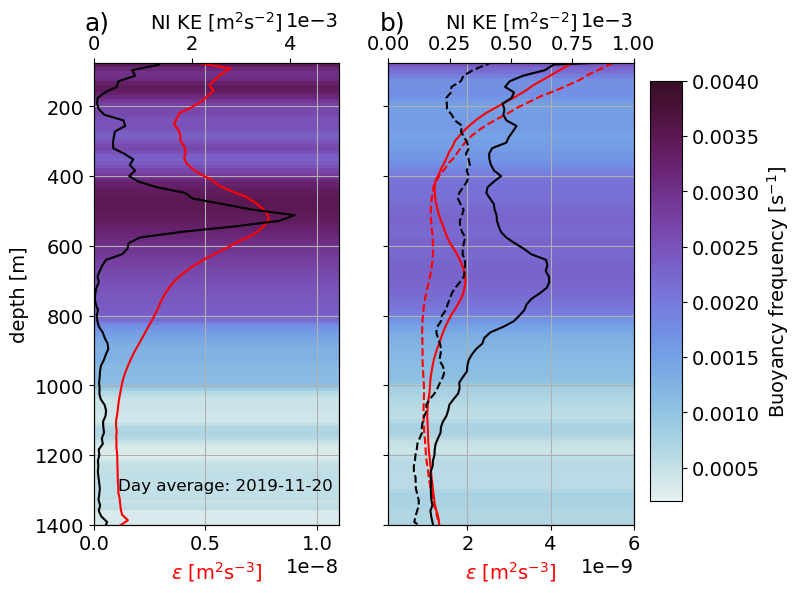

In [42]:
#Plot Figure 5: NI KE, dissipation rates and stratification vertical profiles
t2 = '2019-11-20'
#var = N2.N2.sel(time='2019-11').sel(depth=slice(75,1400)).mean('time')
var = np.sqrt(_ds.dropna('depth')).interp(depth=np.arange(70,1400,10),method='cubic')
varmean = np.sqrt(N2.N2).sel(depth=slice(75,1400)).mean('time')

my_cmap = plt.get_cmap(cmocean.cm.dense) #,var.size
norm = Normalize(2e-4,4e-3)
converted_var = my_cmap(norm(var))
converted_varmean = my_cmap(norm(varmean))



fig,axs=plt.subplots(1,2,figsize=(8,6),sharey=True)
eps.eps.sel(time=t2).mean('time').plot(ax=axs[0],c='r',y='depth_bin',yincrease=False,xlim=(0,1.1e-8))
axs[0].set_xlabel(r'$\epsilon$ [m$^2$s$^{-3}$]',c='r');
ax1=axs[0].twiny()
ds.ni_ke.sel(time=t2).mean('time').plot(ax=ax1,c='k',y='z',yincrease=False,xlim=(0,5e-3))
axs[0].grid();ax1.set_title('');ax1.set_xlabel(r'NI KE [m$^2$s$^{-2}$]')
axs[0].barh(np.arange(75,1400,10),height=75,width=2e-8,color=converted_var)
axs[0].set_ylabel('depth [m]');
axs[0].set_ylim(1400,75)
#ax1.tick_params(labelrotation=90)
ax1.axes.ticklabel_format(axis='x', style='sci',scilimits=((0,0)))
axs[0].text(1.1e-9,1300,'Day average: 2019-11-20',size=12)
axs[0].text(-0.4e-9,-20,'a)',size=18)

ax=axs[1]
summer_line = mlines.Line2D([], [], color='k', linestyle='--', label=r'$\zeta$/f > 0')
winter_line = mlines.Line2D([], [], color='k', ls='-', label=r'$\zeta$/f < 0')
ax1 = ax.twiny()
(ds.ni_ke.where(vort.vorticity_norm.mean('z')<0,drop=True).mean('time')).plot(ax=ax1,c='k',y='z',yincrease=False,xlim=(0,1e-3))
(ds.ni_ke.where(vort.vorticity_norm.mean('z')>0,drop=True).mean('time')).plot(ax=ax1,c='k',ls='--',y='z',yincrease=False,xlim=(0,1e-3))
(eps.eps.where(vort.vorticity_norm.mean('z')<0,drop=True).mean('time')).plot(ax=ax,c='r',y='depth_bin',yincrease=False,xlim=(1e-10,6e-9))
(eps.eps.where(vort.vorticity_norm.mean('z')>0,drop=True).mean('time')).plot(ax=ax,c='r',y='depth_bin',yincrease=False,xlim=(1e-10,6e-9),ls='--')
ax.set_title('');
ax.barh(np.arange(75,1400,10),height=75,width=2e-8,color=converted_varmean)
ax1.set_xlabel(r'NI KE [m$^2$s$^{-2}$]');
ax.set_ylabel('');
ax.grid();ax.set_xlabel(r'$\epsilon$ [m$^2$s$^{-3}$]',c='r');
ax1.axes.ticklabel_format(axis='x', style='sci',scilimits=((0,0)))
axs[1].text(-0.1e-9,-20,'b)',size=18)

sm = ScalarMappable(cmap=my_cmap, norm=Normalize(2e-4,4e-3))
sm.set_array([])

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.04, 0.7])
cbar = plt.colorbar(sm, cax=cbar_ax,label='Buoyancy frequency [s$^{-1}$]')
fig.savefig(figdir+'eps_nike_profiles.png')